<a href="https://colab.research.google.com/github/scardenol/Numerical_Analysis_2026/blob/main/Taller%202/2_riccati_lqr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Punto 2 — Regulador lineal-cuadrático: Riccati e integración numérica

Consideremos el descenso vertical de un dron. Definamos el estado $x=(x_1,x_2)$ con $x_1$ la altura sobre el suelo (m) y $x_2$ la velocidad vertical (m/s, positiva hacia arriba), y el control $u$ la aceleración neta aplicada por los motores (m/s²), ya descontado el efecto de la gravedad. La dinámica es el **doble integrador**:

\begin{gather*}
\dot x_1 = x_2, \quad \dot x_2 = u \quad \iff \quad \dot x = Ax+Bu, \quad A=\begin{pmatrix}0&1\\0&0\end{pmatrix}, \quad B=\begin{pmatrix}0\\1\end{pmatrix}.
\end{gather*}

Queremos llevar al dron cerca de altura 0 con velocidad 0 (reposo en tierra) gastando el menor combustible posible, penalizando también estar lejos de esa condición en el camino:

\begin{gather*}
\text{mín } J=\int_0^T (x^TQx+u^TRu)\,dt, \quad Q=2I=\begin{pmatrix}2&0\\0&2\end{pmatrix}, \quad R=1,
\end{gather*}

sujeto a la dinámica de arriba, con $x(0)=(100,-20)$ (100 m de altura, descendiendo a 20 m/s) y $T=8$ (segundos). El estado final $x(T)$ queda **libre**: no se exige tocar tierra exactamente en el instante $T$; en cambio, el costo $Q$ penaliza estar lejos del reposo en tierra durante todo el trayecto.

Este problema (**lineal–cuadrático**, o LQR) se resuelve con una matriz simétrica $P(t)\in\mathbb R^{2\times2}$ que satisface la **ecuación diferencial de Riccati**

\begin{gather*}
-\dot P(t)=A^TP(t)+P(t)A-P(t)BR^{-1}B^TP(t)+2Q, \quad P(T)=0,
\end{gather*}

(que se integra **hacia atrás** en el tiempo, de $t=T$ a $t=0$, porque la condición conocida es $P(T)$) y que da lugar a la ley de control óptimo por **retroalimentación de estado**:

\begin{gather*}
u^*(t)=-R^{-1}B^TP(t)\,x^*(t).
\end{gather*}

El objetivo es:
1. Implementar un integrador **propio** de la ecuación diferencial de Riccati usando un método de diferencias finitas, integrando hacia atrás desde $P(T)=0$ hasta $t=0$.
2. Resolver la misma ecuación con un integrador **Runge–Kutta** de biblioteca, comparar $P(t)$ contra la implementación propia y estudiar el error al refinar $\Delta t$.
3. Propagar hacia **adelante** el estado del dron aplicando la ley de retroalimentación óptima.
4. Discutir qué es un método de paso **adaptativo** y por qué RK45 lo es.

In [1]:
# Cargar librerías
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1) Integrador propio de la ecuación de Riccati (Euler explícito)

La ecuación de Riccati la escribimos como $\dot P(t) = f(P(t))$ con

\begin{gather*}
f(P) = -\big(A^TP+PA-PBR^{-1}B^TP+2Q\big), \qquad P(T)=0.
\end{gather*}

Como la condición conocida es $P(T)$, integramos **hacia atrás**: en cada paso avanzamos el tiempo en $-\Delta t$ usando la aproximación de diferencias finitas hacia adelante de la derivada (Euler explícito)

\begin{gather*}
P(t-\Delta t) \approx P(t) - \Delta t\, f(P(t)),
\end{gather*}

partiendo de $P(T)=0$ y repitiendo hasta llegar a $t=0$.

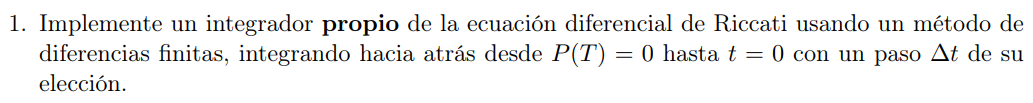

In [2]:
def riccati_dot(P, A, B, Q, R):
  """
  Lado derecho de la ecuación diferencial de Riccati Ṗ(t) = f(P(t)):

      f(P) = -(A^T P + P A - P B R^{-1} B^T P + 2Q)

  Entradas:
  - P: matriz simétrica P(t), np.array 2D (n x n).
  - A, B: matrices de la dinámica del sistema.
  - Q, R: matrices de peso del costo cuadrático (R debe ser invertible).

  Salidas:
  - dP: derivada Ṗ(t), np.array 2D (n x n).
  """
  R_inv = np.linalg.inv(R)
  return -(A.T @ P + P @ A - P @ B @ R_inv @ B.T @ P + 2*Q)

In [3]:
def riccati_euler_propio(A, B, Q, R, T, dt):
  """
  Integrador propio (Euler explícito) de la ecuación de Riccati, integrando
  hacia atrás desde t=T (con P(T)=0) hasta t=0.

  Entradas:
  - A, B, Q, R: matrices del problema LQR.
  - T: horizonte temporal.
  - dt: paso de tiempo deseado (se ajusta levemente para que T/dt sea entero).

  Salidas:
  - ts: vector de tiempos decreciente desde T hasta 0, shape (N+1,).
  - Ps: arreglo con P(t) en cada tiempo de ts, shape (N+1, n, n).
  """
  n = A.shape[0]
  N = int(np.ceil(T / dt))       # número de pasos, redondeado hacia arriba
  dt_efectivo = T / N            # ajuste para que los N pasos cubran [0, T] exacto
  ts = np.linspace(T, 0, N + 1)  # tiempos decrecientes: T, T-dt, ..., 0
  Ps = np.zeros((N + 1, n, n))
  Ps[0] = np.zeros((n, n))       # condición P(T) = 0

  for k in range(N):
    dP = riccati_dot(Ps[k], A, B, Q, R)
    Ps[k + 1] = Ps[k] - dt_efectivo * dP   # Euler explícito, avanzando t en -dt_efectivo

  return ts, Ps

Definimos el problema LQR ($A$, $B$, $Q$, $R$, $x(0)$, $T$) y resolvemos con el integrador propio usando $\Delta t = 0.01$.

In [4]:
# Definición del problema LQR
A = np.array([[0., 1.],
              [0., 0.]])
B = np.array([[0.],
              [1.]])
Q = 2 * np.eye(2)
R = np.array([[1.]])
x0 = np.array([100., -20.])
T = 8.0

dt_propio = 0.01
ts_propio, Ps_propio = riccati_euler_propio(A, B, Q, R, T, dt_propio)

print(f"Número de pasos: {len(ts_propio) - 1}, paso efectivo: {ts_propio[0] - ts_propio[1]:.5f}")
print(f"P(0) obtenido con Euler propio:\n{Ps_propio[-1]}")

Número de pasos: 800, paso efectivo: 0.01000
P(0) obtenido con Euler propio:
[[5.65685413 1.99999992]
 [1.99999992 2.82842707]]


# 2) Integración con Runge–Kutta de biblioteca (RK45 de `scipy.integrate.solve_ivp`)

`solve_ivp` exige que el estado sea un vector 1D, así que aplanamos $P$ a un vector de tamaño $n^2$ para poder reutilizar `riccati_dot`. Integramos con `method='RK45'` directamente en `t_span=(T, 0)` (`solve_ivp` admite integrar hacia atrás si $t$ es decreciente), evaluando en los mismos tiempos `ts_propio` de la implementación propia para poder comparar punto a punto.

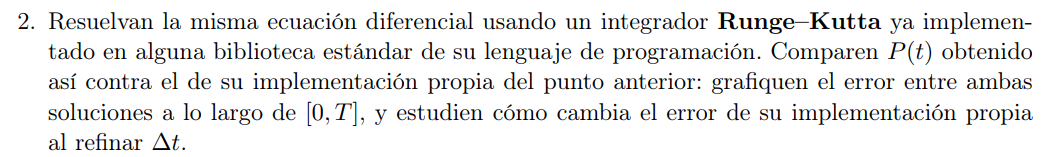

In [5]:
def riccati_dot_vec(t, y, A, B, Q, R, n):
  """
  Versión vectorizada de riccati_dot para usar con solve_ivp, que exige que el
  estado sea un vector 1D. Aplana P a un vector de tamaño n*n y lo reconstruye.
  """
  P = y.reshape(n, n)
  dP = riccati_dot(P, A, B, Q, R)
  return dP.flatten()

n = A.shape[0]
sol_rk45 = solve_ivp(riccati_dot_vec, t_span=(T, 0), y0=np.zeros(n * n),
                      t_eval=ts_propio, args=(A, B, Q, R, n),
                      method='RK45', rtol=1e-10, atol=1e-12, dense_output=True)

Ps_rk45 = sol_rk45.y.T.reshape(-1, n, n)   # mismo orden de tiempos que ts_propio

print(f"P(0) obtenido con RK45 de scipy:\n{Ps_rk45[-1]}")

P(0) obtenido con RK45 de scipy:
[[5.65685409 1.9999999 ]
 [1.9999999  2.82842706]]


Comparamos ambas soluciones con el error de Frobenius $\|P_{propio}(t)-P_{RK45}(t)\|_F$ a lo largo de $[0,T]$.

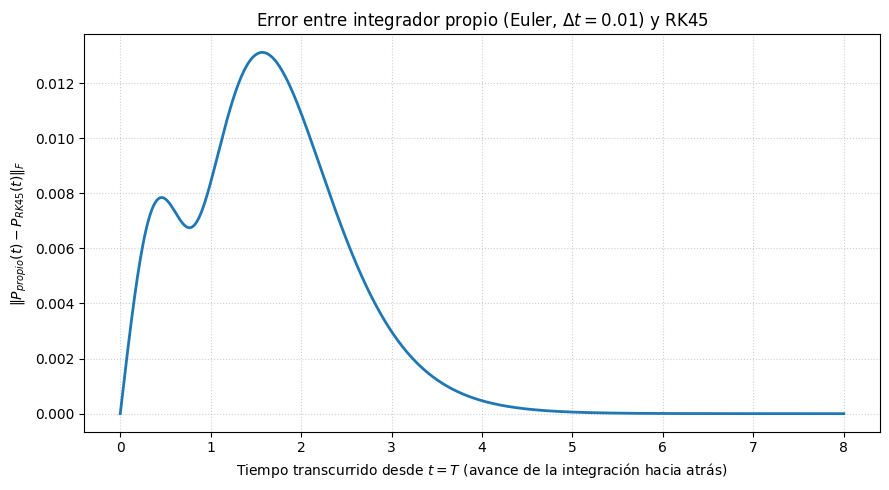

In [6]:
# Error de Frobenius entre la solución propia (Euler) y la de referencia (RK45)
error_t = np.linalg.norm(Ps_propio - Ps_rk45, axis=(1, 2))

plt.figure(figsize=(9, 5))
plt.plot(T - ts_propio, error_t, lw=2, color='#1f77b4')
plt.xlabel('Tiempo transcurrido desde $t=T$ (avance de la integración hacia atrás)')
plt.ylabel(r'$\|P_{propio}(t) - P_{RK45}(t)\|_F$')
plt.title(f'Error entre integrador propio (Euler, $\\Delta t={dt_propio}$) y RK45')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Ahora veamos cómo cambia el error máximo de la implementación propia al refinar $\Delta t$, usando en cada caso una solución RK45 de alta precisión evaluada en los mismos tiempos que la propia como referencia.

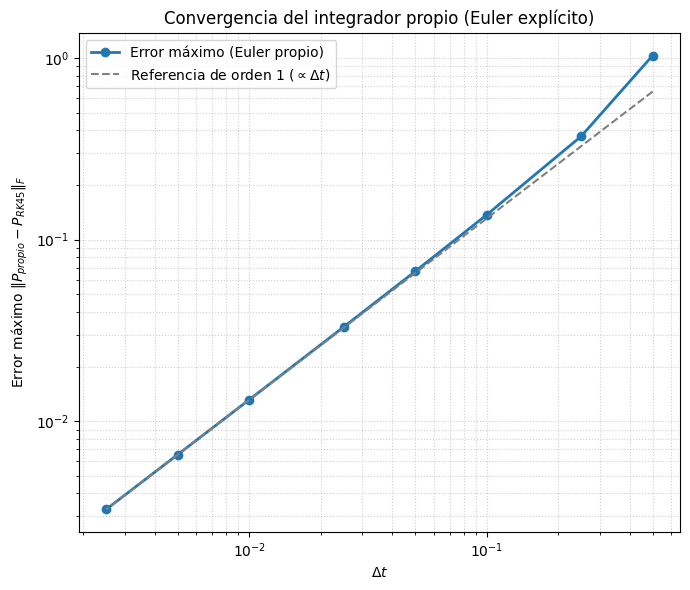

In [7]:
# Estudio de convergencia: error máximo vs. paso de tiempo dt
dts = np.array([0.5, 0.25, 0.1, 0.05, 0.025, 0.01, 0.005, 0.0025])
errores_max = np.zeros_like(dts)

for i, dt_i in enumerate(dts):
  ts_i, Ps_i = riccati_euler_propio(A, B, Q, R, T, dt_i)

  # Solución de referencia (alta precisión) evaluada en los mismos tiempos que la propia
  sol_ref = solve_ivp(riccati_dot_vec, t_span=(T, 0), y0=np.zeros(n * n),
                       t_eval=ts_i, args=(A, B, Q, R, n),
                       method='RK45', rtol=1e-10, atol=1e-12)
  Ps_ref = sol_ref.y.T.reshape(-1, n, n)

  errores_max[i] = np.max(np.linalg.norm(Ps_i - Ps_ref, axis=(1, 2)))

# Gráfica log-log del error máximo vs dt, junto con una recta de referencia de orden 1
plt.figure(figsize=(7, 6))
plt.loglog(dts, errores_max, 'o-', lw=2, color='#1f77b4', label='Error máximo (Euler propio)')
plt.loglog(dts, errores_max[-1] * (dts / dts[-1]), '--', color='gray',
           label=r'Referencia de orden 1 ($\propto \Delta t$)')
plt.xlabel(r'$\Delta t$')
plt.ylabel(r'Error máximo $\|P_{propio}-P_{RK45}\|_F$')
plt.title('Convergencia del integrador propio (Euler explícito)')
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

**Análisis:** el error máximo decrece de forma prácticamente lineal con $\Delta t$ (note que en la gráfica log-log, la curva sigue casi exactamente la pendiente de la referencia de orden 1). Esto es consistente con que el método de Euler explícito es un esquema de primer orden: al reducir $\Delta t$ a la mitad, el error máximo también se reduce aproximadamente a la mitad, mientras que RK45 (con tolerancias ajustadas) alcanza un error muchísimo menor con un costo comparable de evaluaciones.

# 3) Propagación hacia adelante del estado con la ley de control óptimo

Usamos la salida densa (`dense_output=True`) de la solución RK45 del Punto 2 para tener $P(t)$ como una función continua e interpolada, y con ella evaluamos la ley de control $u^*(t)=-R^{-1}B^TP(t)x^*(t)$ mientras integramos hacia adelante la dinámica en lazo cerrado $\dot x^* = Ax^*+Bu^*$, partiendo de $x(0)=(100,-20)$.

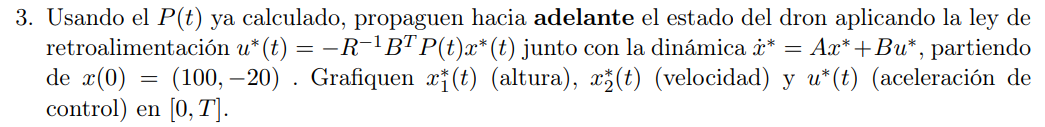

In [8]:
def P_de_t(t):
  """Evalúa P(t) usando la solución densa de RK45 (interpolación continua)."""
  return sol_rk45.sol(t).reshape(n, n)

def ley_control(t, x, B, R, P_func):
  """Ley de control óptimo por retroalimentación de estado u*(t) = -R^{-1}B^T P(t) x(t)."""
  R_inv = np.linalg.inv(R)
  P_t = P_func(t)
  return -R_inv @ B.T @ P_t @ x

def dinamica_lazo_cerrado(t, x, A, B, R, P_func):
  """Dinámica en lazo cerrado ẋ = Ax + Bu*(t, x)."""
  u = ley_control(t, x, B, R, P_func)
  return A @ x + (B @ u)

In [9]:
t_eval_x = np.linspace(0, T, 400)
sol_x = solve_ivp(dinamica_lazo_cerrado, t_span=(0, T), y0=x0, t_eval=t_eval_x,
                   args=(A, B, R, P_de_t), method='RK45', rtol=1e-9, atol=1e-11)

x1_t, x2_t = sol_x.y
u_t = np.array([ley_control(t, x, B, R, P_de_t)[0] for t, x in zip(sol_x.t, sol_x.y.T)])

print(f"Estado final x(T) = ({x1_t[-1]:.3f}, {x2_t[-1]:.3f})")

Estado final x(T) = (0.019, -0.021)


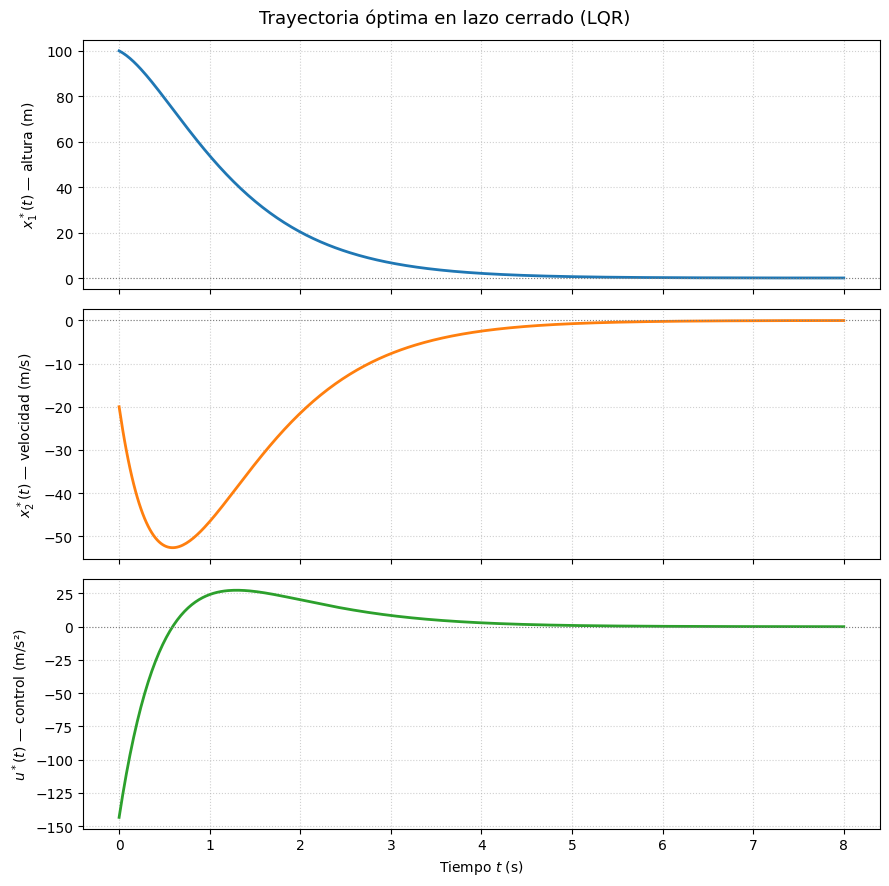

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

axes[0].plot(sol_x.t, x1_t, color='#1f77b4', lw=2)
axes[0].set_ylabel('$x_1^*(t)$ — altura (m)')
axes[0].axhline(0, color='gray', lw=0.8, linestyle=':')
axes[0].grid(True, linestyle=':', alpha=0.6)

axes[1].plot(sol_x.t, x2_t, color='#ff7f0e', lw=2)
axes[1].set_ylabel('$x_2^*(t)$ — velocidad (m/s)')
axes[1].axhline(0, color='gray', lw=0.8, linestyle=':')
axes[1].grid(True, linestyle=':', alpha=0.6)

axes[2].plot(sol_x.t, u_t, color='#2ca02c', lw=2)
axes[2].set_ylabel('$u^*(t)$ — control (m/s²)')
axes[2].set_xlabel('Tiempo $t$ (s)')
axes[2].axhline(0, color='gray', lw=0.8, linestyle=':')
axes[2].grid(True, linestyle=':', alpha=0.6)

fig.suptitle('Trayectoria óptima en lazo cerrado (LQR)', fontsize=13)
plt.tight_layout()
plt.show()

**Análisis:** el controlador aplica al inicio una aceleración fuerte hacia arriba (frenado) para contrarrestar la velocidad de descenso inicial de $-20$ m/s, y luego la va relajando a medida que $x_1^*(t)$ y $x_2^*(t)$ se acercan a 0. Como el estado final está **libre** ($x(T)$ no está fijado), el control también se relaja hacia el final del horizonte en vez de forzar exactamente $x(T)=(0,0)$.

# 4) Discusión escrita: métodos de paso adaptativo y RK45

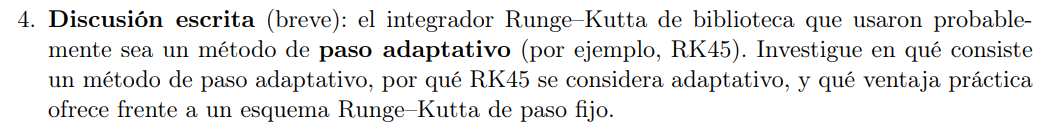

- Un método de paso **adaptativo** ajusta automáticamente el tamaño del paso $\Delta t$ durante la integración, en función de una estimación del error local de truncamiento en cada paso, en lugar de usar un $\Delta t$ fijo de principio a fin como el Euler propio del Punto 1.
- **RK45** (Runge–Kutta–Fehlberg) es adaptativo porque en cada paso calcula **dos** aproximaciones de distinto orden (típicamente orden 4 y orden 5) reutilizando las mismas evaluaciones de la función mediante un esquema *embebido*. La diferencia entre ambas aproximaciones da un estimador barato del error local, sin evaluar la función adicionalmente.
- Si el error estimado supera la tolerancia (`rtol`, `atol`), el paso se **rechaza** y se repite con un $\Delta t$ menor; si el error es mucho menor que la tolerancia, el siguiente paso se **agranda**, ahorrando evaluaciones donde la solución es suave.
- **Ventaja práctica** frente a un esquema Runge–Kutta de paso fijo: en este problema, $P(t)$ cambia rápido cerca de $t=T$ (justo donde arranca la integración hacia atrás, ya que $\dot P$ es grande al alejarse de $P(T)=0$) y luego se aproxima a un régimen casi estacionario para $t$ pequeño. Un esquema adaptativo como RK45 usa pasos pequeños automáticamente donde $P(t)$ cambia rápido y pasos grandes donde es casi constante, logrando alta precisión con muchas menos evaluaciones que un esquema de paso fijo, que tendría que usar en **todo** el intervalo el $\Delta t$ más pequeño exigido por la zona más difícil, incluso donde no hace falta esa resolución. Esto explica por qué, en la comparación del Punto 2, la solución RK45 alcanza un error mucho menor que la de Euler para un costo computacional comparable.